Team : Anna Moy & Natalie Kalukeerthie

For this assignment we had to use the data UCI Machine Learning Respository: Spambase Data set. We have to determine if the dataset will predict the class of the new document.


The first step we did was load the spambase.data and spambase.names into a dataset. Next was to split up the data into features and labels. We took a look at the distribution of the spam and ham emails by count and percentage.


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


# Load dataset from URL
url = "https://raw.githubusercontent.com/AnnaMoy/Data-620/refs/heads/main/spambase.data"
column_names_url = "https://raw.githubusercontent.com/AnnaMoy/Data-620/refs/heads/main/spambase.names"

df = pd.read_csv(url, header=None)

# Last column is the target class = (1=spam, 0=ham)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Overall class distribution
print("Overall dataset class distribution:")
print(y.value_counts())
print("\nOverall percentage distribution:")
print(y.value_counts(normalize=True) * 100)


Overall dataset class distribution:
57
0    2788
1    1813
Name: count, dtype: int64

Overall percentage distribution:
57
0    60.595523
1    39.404477
Name: proportion, dtype: float64


We wanted to make sure the proportion between the ham and spam are the same in the test and training set and did the split at 80/20. Then we want to check if there is any missing values in our data. Next we conducted a feature scaling which will standardize the features and have mean = 0 and standard deviation = 1.

In [ ]:
# Stratified train/test split to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train/test class distribution
print("\nTrain set class distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTest set class distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

# Check for missing values
print(f"Missing values in dataset: {df.isnull().sum().sum()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Train set class distribution:
57
0    2230
1    1450
Name: count, dtype: int64
57
0    60.597826
1    39.402174
Name: proportion, dtype: float64

Test set class distribution:
57
0    558
1    363
Name: count, dtype: int64
57
0    60.586319
1    39.413681
Name: proportion, dtype: float64
Missing values in dataset: 0


Split of the data and the class remains as 60% in ham and 30% in spam. Therefore we created a synthetic sample  to have the ham and spam data the same for the training data.


In [ ]:
# Balance the training data using SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Balanced training set class distribution:")
print(pd.Series(y_train_bal).value_counts())


Balanced training set class distribution:
57
0    2230
1    2230
Name: count, dtype: int64


We ran the Gaussian Naive Bayess Model and looked at the results on how well it was on predicting if the email is spam or ham.

The accuracy score was 83% which shows it was pretty good in predicting the emails.

**Precision** - How many email were predict as spam or ham? 97% of the email was reported as ham correctly and 75% as spam.

**Recall** - How many actual emails in spam and ham were predicted correctly? The results show it was very good at predicting spam as it was 96% correct vs 75% in spam.

**F1-score** - This measures the balance between precision and recall and both had very similar percentages.

Support - shows the number of spam and ham emails.

Macro average -  Average of the metrics without considering if it it is spam or ham. Percentage is fairly the same which means they are treated equally.

Weighted average - Average weighted by number of examples per class. Percentage is same because it is even split.

In [ ]:
# Gaussian Naive Bayes model
gnb = GaussianNB()

# Train the model on the scaled training data
gnb.fit(X_train_bal, y_train_bal)

# Predict on the test set
y_pred = gnb.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Test Accuracy: 0.8339

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.75      0.85       558
           1       0.72      0.96      0.82       363

    accuracy                           0.83       921
   macro avg       0.84      0.86      0.83       921
weighted avg       0.87      0.83      0.84       921



We did a matrix to show the model's predictions vs actual classes.

*   420 emails were classified correctly as ham (True Negatives)
*   138 ham emails were misclassified as spam (False Positives)
*   15 spam emails were misclassified as ham (False Negatives)
*   348 emails were classified correctly as spam (True positives)


This explains why we had recall score of 75% since we had many ham misclassified as spam (139).

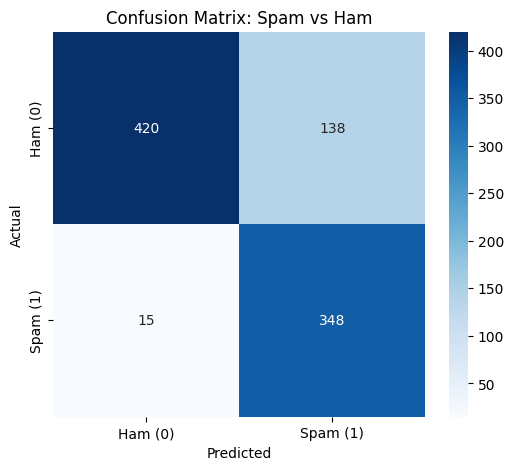

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Labels
labels = ['Ham (0)', 'Spam (1)']

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Spam vs Ham")
plt.show()
